In [51]:
import pandas as pd
import numpy as np
import xgboost as xgb
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [52]:
# --- CONFIGURATION ---
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dataset").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = PROJECT_ROOT / "output"
MODEL_PATH = PROJECT_ROOT / "Xgboost" / "cricket_team_model_v5.json"
MAE_OVERS_PLAYED_PLOT_PATH = OUTPUT_DIR / "mae_v5_overs_played.png"
MATCH_COUNT_MAE_DIR = OUTPUT_DIR / "match_count_mae_range"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MATCH_COUNT_MAE_DIR.mkdir(parents=True, exist_ok=True)

# 1. LOAD DATA
try:
    df = pd.read_csv(DATASET_DIR / "final_ball_by_ball_first_innings.csv")
    bat_stats = pd.read_csv(DATASET_DIR / "batter_stats_v2.csv")
    bowl_stats = pd.read_csv(DATASET_DIR / "bowler_stats_v2.csv")
except FileNotFoundError as e:
    print(f"Error: {e}. Ensure dataset files are in {DATASET_DIR}")
    exit()

In [53]:
# 2. CALCULATE TEAM-LEVEL AVERAGES (No Future Bias Logic)
def get_match_team_stats(df, bat_stats, bowl_stats):
    match_batters = df.groupby('match_id')['batter'].unique().reset_index()
    match_bowlers = df.groupby('match_id')['bowler'].unique().reset_index()

    def get_avg_bat(player_list):
        stats = bat_stats[bat_stats['batter'].isin(player_list)]
        return stats['strike_rate'].mean(), stats['average'].mean()

    def get_avg_bowl(player_list):
        stats = bowl_stats[bowl_stats['bowler'].isin(player_list)]
        return stats['economy'].mean()

    match_batters[['team_sr', 'team_avg']] = pd.DataFrame(match_batters['batter'].apply(get_avg_bat).tolist(), index=match_batters.index)
    match_bowlers['team_eco'] = match_bowlers['bowler'].apply(get_avg_bowl)

    df = df.merge(match_batters[['match_id', 'team_sr', 'team_avg']], on='match_id', how='left')
    df = df.merge(match_bowlers[['match_id', 'team_eco']], on='match_id', how='left')
    return df

In [54]:
df = get_match_team_stats(df, bat_stats, bowl_stats)

# 3. FEATURE ENGINEERING
df = df.sort_values(by=["match_id", "over", "ball"]).reset_index(drop=True)
df["runs_so_far"] = df.groupby("match_id")["runs_total"].cumsum()
df["wickets_so_far"] = df.groupby("match_id")["wicket_fallen"].cumsum()
df["balls_so_far"] = df.groupby("match_id").cumcount() + 1
df["current_run_rate"] = (df["runs_so_far"] / (df["balls_so_far"] / 6.0)).replace([np.inf, -np.inf], 0)
df["balls_remaining"] = 120 - df["balls_so_far"]
df["wickets_remaining"] = 10 - df["wickets_so_far"]
df["runs_last_3_overs"] = np.where(df["balls_so_far"] <= 18, 0, df.groupby("match_id")["runs_total"].transform(lambda x: x.rolling(18, 1).sum()))

# Phase logic: 1: Powerplay, 2: Middle, 3: Death
df['match_phase'] = pd.cut(df['over'], bins=[-1, 6, 15, 20], labels=[1, 2, 3]).astype(int)

# Venue Stats
venue_means = df.groupby("venue")["runs_total"].sum() / df.groupby("venue")["match_id"].nunique()
df["venue_avg_score"] = df["venue"].map(venue_means)

# Target
final_scores = df.groupby("match_id")["runs_total"].sum().reset_index().rename(columns={"runs_total": "final_score"})
df = df.merge(final_scores, on="match_id")

# 4. TRAINING
FEATURE_COLS = [
    "runs_so_far", "wickets_so_far", "balls_so_far", "current_run_rate",
    "balls_remaining", "wickets_remaining", "venue_avg_score", 
    "team_sr", "team_avg", "team_eco", "match_phase", "runs_last_3_overs"
]

X = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
y = df["final_score"]


In [55]:
X.columns

Index(['runs_so_far', 'wickets_so_far', 'balls_so_far', 'current_run_rate',
       'balls_remaining', 'wickets_remaining', 'venue_avg_score', 'team_sr',
       'team_avg', 'team_eco', 'match_phase', 'runs_last_3_overs'],
      dtype='object')

In [56]:
X.head()

,runs_so_far,wickets_so_far,balls_so_far,current_run_rate,balls_remaining,wickets_remaining,venue_avg_score,team_sr,team_avg,team_eco,match_phase,runs_last_3_overs
0,0,0,1,0.0,119,10,160.1,117.064591,20.107639,8.799052,1,0.0
1,1,0,2,3.0,118,10,160.1,117.064591,20.107639,8.799052,1,0.0
2,1,0,3,2.0,117,10,160.1,117.064591,20.107639,8.799052,1,0.0
3,1,0,4,1.5,116,10,160.1,117.064591,20.107639,8.799052,1,0.0
4,1,0,5,1.2,115,10,160.1,117.064591,20.107639,8.799052,1,0.0


In [57]:
X.describe()

,runs_so_far,wickets_so_far,balls_so_far,current_run_rate,balls_remaining,wickets_remaining,venue_avg_score,team_sr,team_avg,team_eco,match_phase,runs_last_3_overs
count,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000,599294.000000
mean,65.938721,2.733880,62.502850,6.119547,57.497150,7.266120,136.371020,100.127367,19.327429,6.760976,1.821552,17.078864
std,46.881137,2.271521,36.444542,2.403227,36.444542,2.271521,22.059192,25.470546,6.403883,1.240809,0.719847,10.765329
min,0.000000,0.000000,1.000000,0.000000,-70.000000,0.000000,28.000000,1.298701,0.090909,2.053333,1.000000,0.000000
25%,28.000000,1.000000,31.000000,4.575000,27.000000,6.000000,121.750000,82.737452,15.139201,5.972498,1.000000,10.000000
50%,59.000000,2.000000,62.000000,6.000000,58.000000,8.000000,138.526316,104.598233,19.072444,6.828890,2.000000,17.000000
75%,97.000000,4.000000,93.000000,7.591837,89.000000,9.000000,149.266667,119.656376,23.403794,7.649557,2.000000,24.000000
max,344.000000,10.000000,190.000000,42.000000,119.000000,10.000000,316.500000,166.950594,93.555556,12.732650,3.000000,77.000000


In [58]:
X.nunique()

runs_so_far            326
wickets_so_far          11
balls_so_far           190
current_run_rate     12420
balls_remaining        190
wickets_remaining       11
venue_avg_score        391
team_sr               4720
team_avg              4711
team_eco              4245
match_phase              3
runs_last_3_overs       76
dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, objective='reg:squarederror', eval_metric='mae', early_stopping_rounds=20)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=10)
model.save_model(str(MODEL_PATH))

/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(509), np.int64(513), np.int64(472), np.int64(494), np.int64(404), np.int64(404), np.int64(331), np.int64(308), np.int64(228), np.int64(205), np.int64(419), np.int64(248), np.int64(169)]


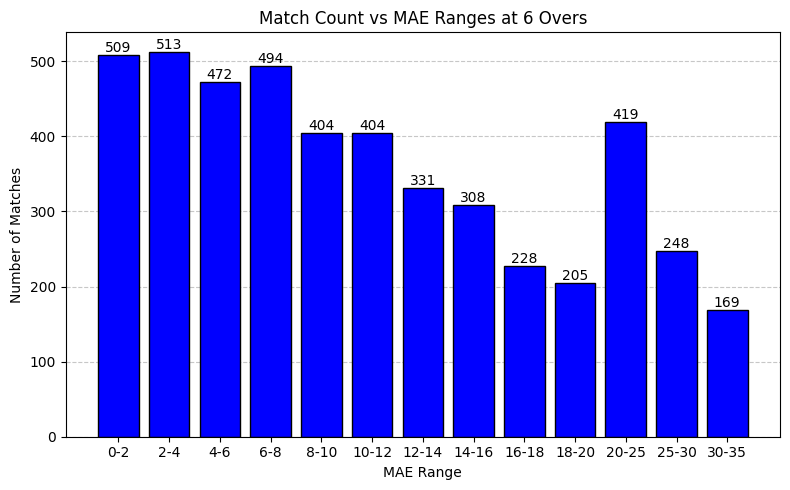

/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(682), np.int64(603), np.int64(544), np.int64(462), np.int64(448), np.int64(402), np.int64(308), np.int64(294), np.int64(255), np.int64(189), np.int64(321), np.int64(154), np.int64(85)]


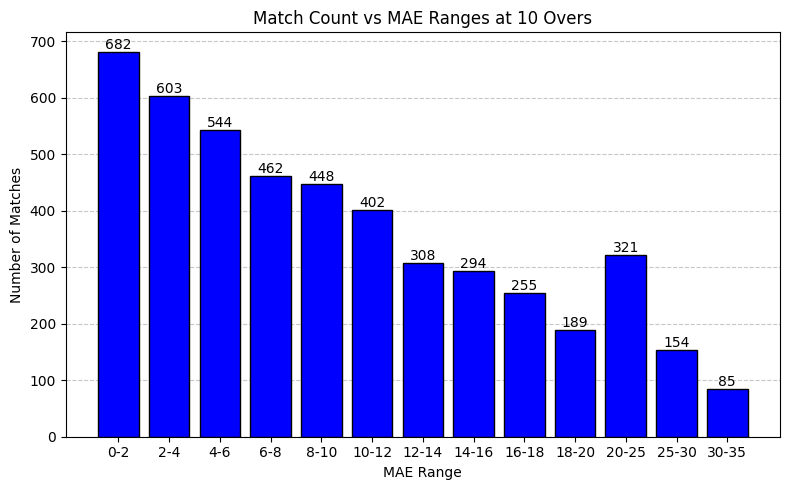

/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(793), np.int64(744), np.int64(706), np.int64(583), np.int64(508), np.int64(399), np.int64(263), np.int64(219), np.int64(135), np.int64(112), np.int64(157), np.int64(46), np.int64(13)]


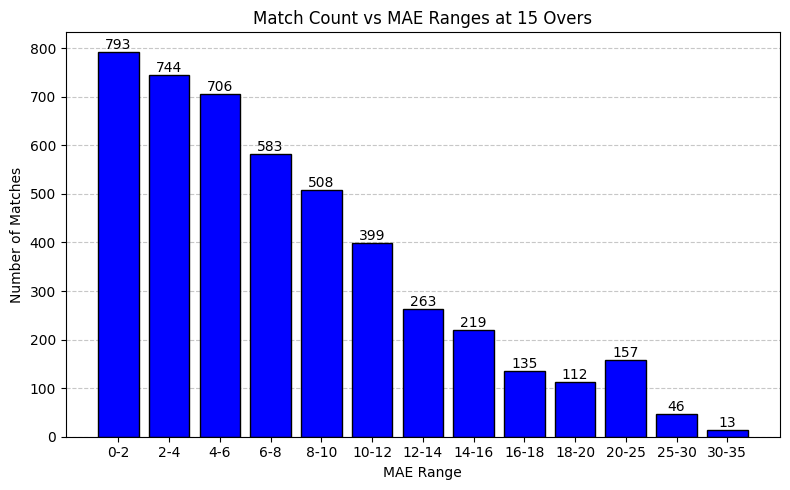

['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(875), np.int64(820), np.int64(717), np.int64(585), np.int64(464), np.int64(399), np.int64(258), np.int64(182), np.int64(131), np.int64(72), np.int64(101), np.int64(31), np.int64(11)]


/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


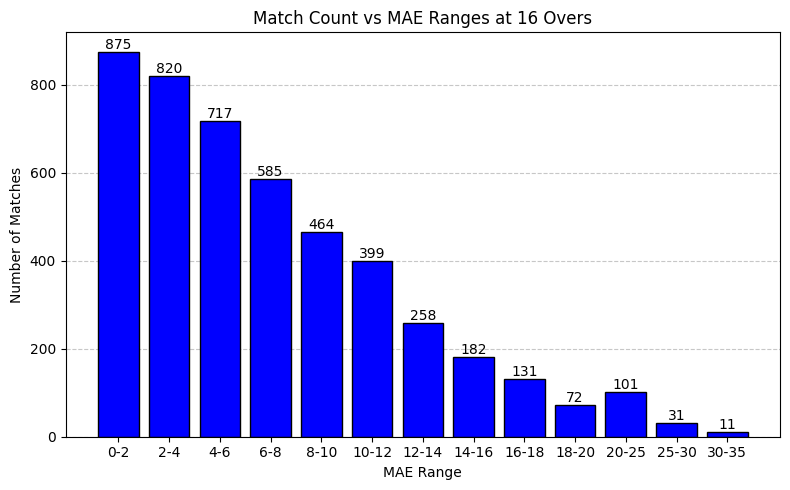

/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(972), np.int64(892), np.int64(743), np.int64(642), np.int64(447), np.int64(323), np.int64(224), np.int64(134), np.int64(79), np.int64(62), np.int64(61), np.int64(16), np.int64(2)]


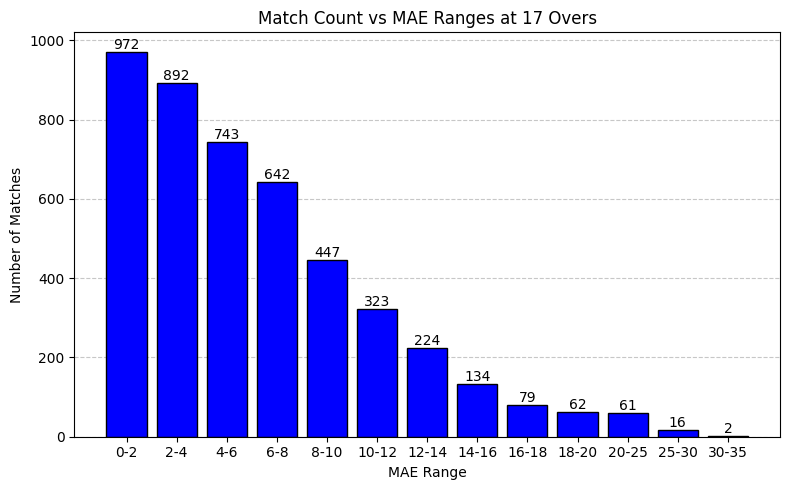

/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(1095), np.int64(943), np.int64(835), np.int64(566), np.int64(436), np.int64(279), np.int64(155), np.int64(99), np.int64(55), np.int64(37), np.int64(31), np.int64(7), np.int64(2)]


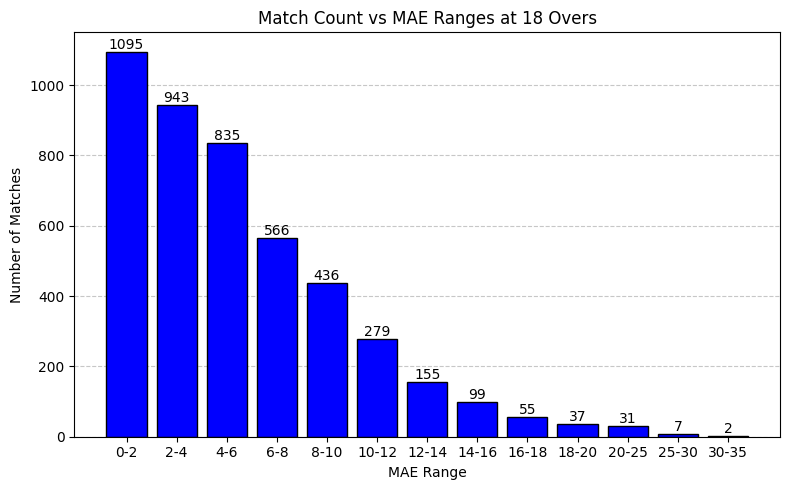

/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(1222), np.int64(1023), np.int64(812), np.int64(574), np.int64(370), np.int64(200), np.int64(110), np.int64(64), np.int64(27), np.int64(13), np.int64(14), np.int64(3), np.int64(0)]


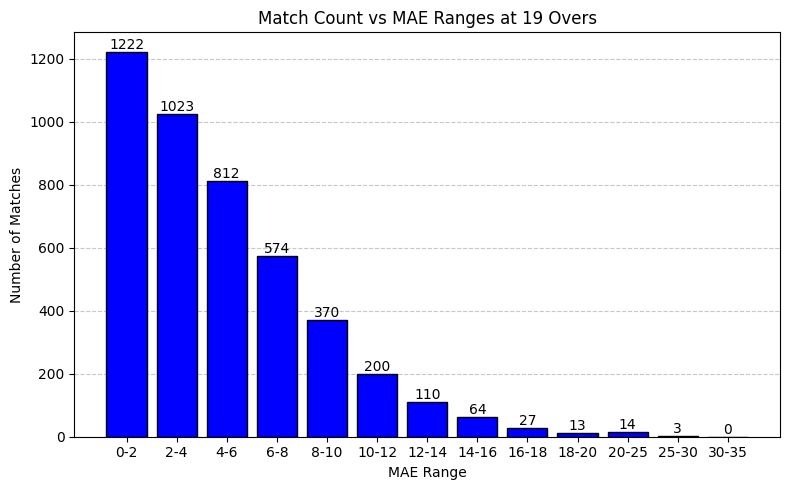

/tmp/ipykernel_77000/2566787274.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["mae"] = abs(subset["actual"] - pred)


['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-25', '25-30', '30-35']
[np.int64(1333), np.int64(1151), np.int64(810), np.int64(513), np.int64(232), np.int64(119), np.int64(60), np.int64(20), np.int64(9), np.int64(1), np.int64(9), np.int64(3), np.int64(1)]


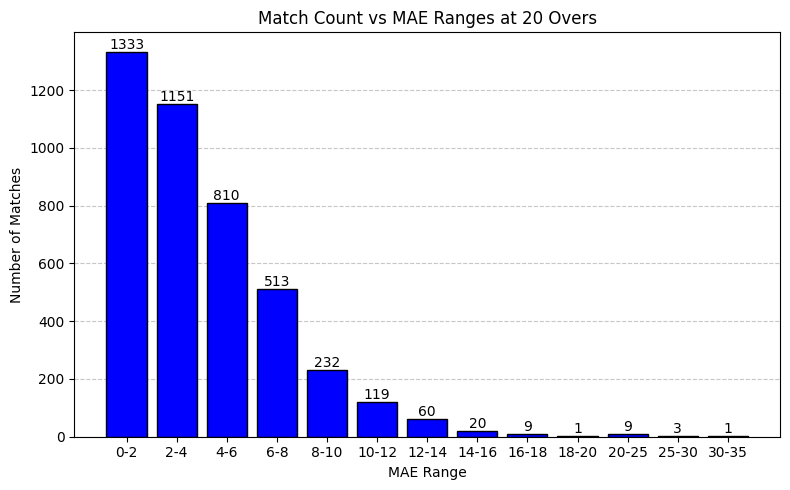

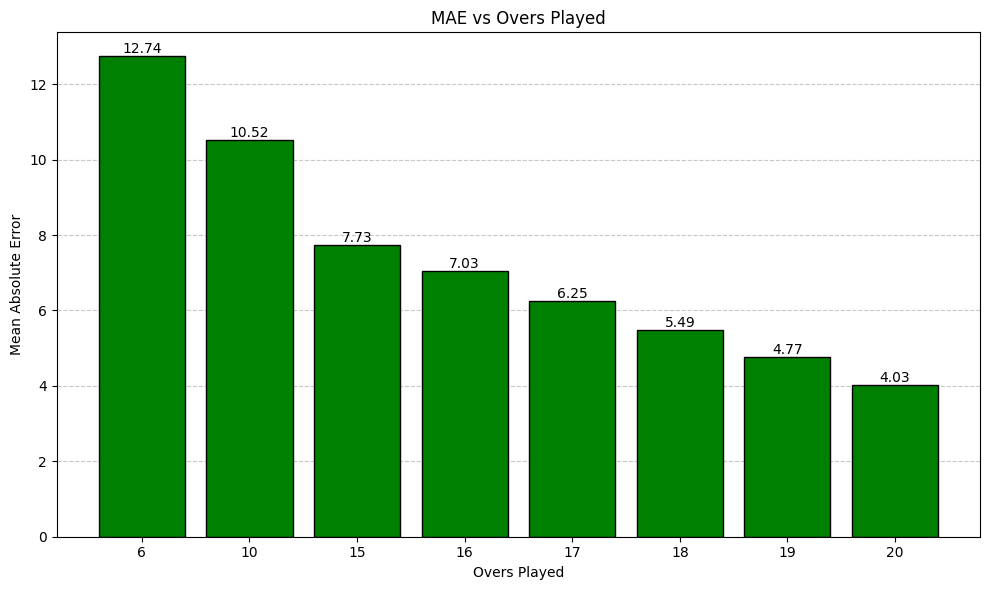

In [10]:
# 5. EVALUATION & PHASED PLOTTING
# mae vs overs played
overs = [6, 10, 15, 16, 17, 18, 19, 20]
over_labels = [str(o) for o in overs]
mae_labels = ["0-2", "2-4", "4-6", "6-8", "8-10", "10-12", "12-14", "14-16", "16-18", "18-20", "20-25", "25-30", "30-35"]
number_of_matches = []
mae = []
eval_df = X.copy()
eval_df["actual"] = y
for o in overs:
    subset = eval_df[eval_df["balls_so_far"] == o * 6]
    if not subset.empty:
        pred = model.predict(subset[FEATURE_COLS])
        mae.append(mean_absolute_error(subset["actual"], pred))
        subset["mae"] = abs(subset["actual"] - pred)
        
        number_of_matches.clear()
        for i, label in enumerate(mae_labels):
            lower, upper = map(float, label.split('-'))
            number_of_matches.append(subset["mae"].between(lower, upper).sum())
        print(mae_labels)
        print(number_of_matches)

        plt.figure(figsize=(8, 5))
        plt.bar(mae_labels, number_of_matches, color='blue', edgecolor='black')
        plt.title(f"Match Count vs MAE Ranges at {o} Overs")
        plt.xlabel("MAE Range")
        plt.ylabel("Number of Matches")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.gca().set_axisbelow(True)
        for i, count in enumerate(number_of_matches):
            plt.text(i, count, str(count), ha='center', va='bottom', fontsize=10)
        plt.tight_layout()
        plt.savefig(MATCH_COUNT_MAE_DIR / f"MATCH_COUNT_MAE_RANGE_{o}_overs.png")
        plt.show()


plt.figure(figsize=(10, 6))

# Use plt.bar to create a column chart
bars = plt.bar(over_labels, mae, color='green', edgecolor='black')

plt.title("MAE vs Overs Played")
plt.xlabel("Overs Played")
plt.ylabel("Mean Absolute Error")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True) 

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(MAE_OVERS_PLAYED_PLOT_PATH)
plt.show()
